# Task 4: Predicting Insurance Claim Amounts

## Introduction
Predicting insurance claim amounts helps insurance companies estimate future costs and set appropriate premiums. By analyzing customer data, we can understand how different factors affect medical expenses.

## Objective
The objective of this task is to build a Linear Regression model to estimate insurance charges based on personal attributes. It also involves visualizing the impact of features like age, BMI, and smoking status, and evaluating the model using MAE and RMSE.

## Dataset
The Medical Cost Personal Dataset includes features such as age, BMI, number of children, smoking status, and region. The target variable represents the medical insurance charges for each individual.

In [2]:
import pandas as pd
#import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
 
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

In [3]:
df = pd.read_csv("insurance.csv")
 
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (1338, 7)

Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
print("Data Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Data Types:
 age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

Missing Values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Basic Statistics:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [5]:
# Check for duplicates
print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
 
# --- Encode categorical columns ---
le = LabelEncoder()
 
# sex: female=0, male=1
df["sex"] = le.fit_transform(df["sex"])
 
# smoker: no=0, yes=1
df["smoker"] = le.fit_transform(df["smoker"])
 
# region: one-hot encode (4 categories)
df = pd.get_dummies(df, columns=["region"], drop_first=True)
 
print("Shape after encoding:", df.shape)
df.head()

Duplicate rows: 1
Shape after encoding: (1337, 9)


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,16884.92400,False,False,True
1,18,1,33.770,1,0,1725.55230,False,True,False
2,28,1,33.000,3,0,4449.46200,False,True,False
3,33,1,22.705,0,0,21984.47061,True,False,False
4,32,1,28.880,0,0,3866.85520,True,False,False


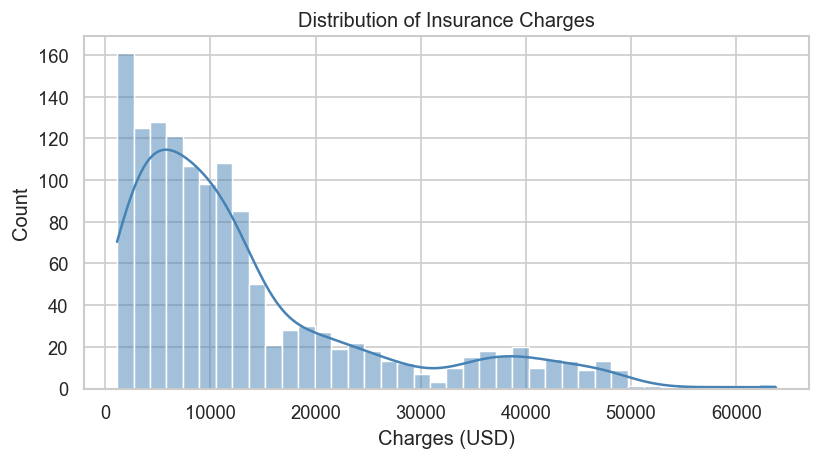

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(df["charges"], bins=40, kde=True, color="steelblue", ax=ax)
ax.set_title("Distribution of Insurance Charges")
ax.set_xlabel("Charges (USD)")
plt.tight_layout()
plt.savefig("charges_distribution.png")
plt.show()

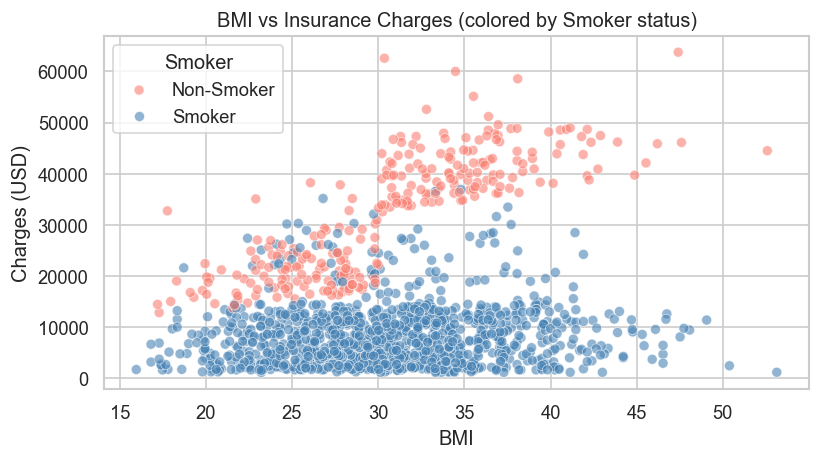

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(x="bmi", y="charges", hue="smoker",
                data=df, palette=["steelblue", "salmon"],
                alpha=0.6, ax=ax)
ax.set_title("BMI vs Insurance Charges (colored by Smoker status)")
ax.set_xlabel("BMI")
ax.set_ylabel("Charges (USD)")
ax.legend(title="Smoker", labels=["Non-Smoker", "Smoker"])
plt.tight_layout()
plt.savefig("bmi_vs_charges.png")
plt.show()

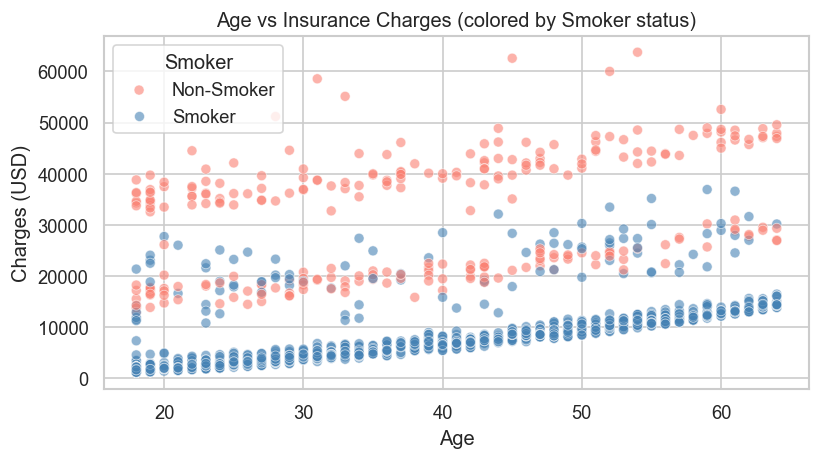

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(x="age", y="charges", hue="smoker",
                data=df, palette=["steelblue", "salmon"],
                alpha=0.6, ax=ax)
ax.set_title("Age vs Insurance Charges (colored by Smoker status)")
ax.set_xlabel("Age")
ax.set_ylabel("Charges (USD)")
ax.legend(title="Smoker", labels=["Non-Smoker", "Smoker"])
plt.tight_layout()
plt.savefig("age_vs_charges.png")
plt.show()

/var/folders/jm/s2f0ymjs3vx9jm3b2n6ytj4c0000gn/T/ipykernel_71566/269324343.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Non-Smoker", "Smoker"])


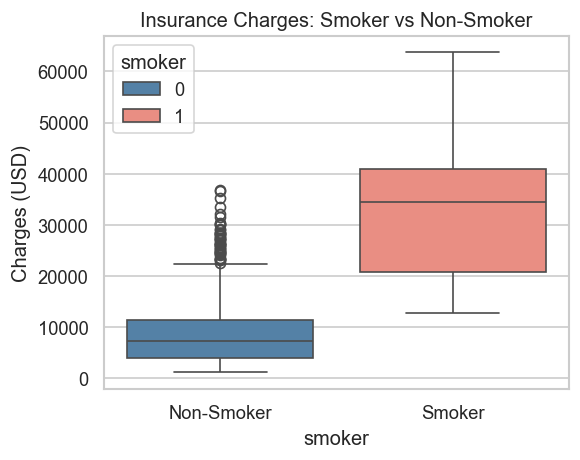

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
sns.boxplot(x="smoker", y="charges",hue="smoker", data=df,
            palette=["steelblue", "salmon"], ax=ax)
ax.set_xticklabels(["Non-Smoker", "Smoker"])
ax.set_title("Insurance Charges: Smoker vs Non-Smoker")
ax.set_ylabel("Charges (USD)")
plt.tight_layout()
plt.savefig("smoker_vs_charges.png")
plt.show()

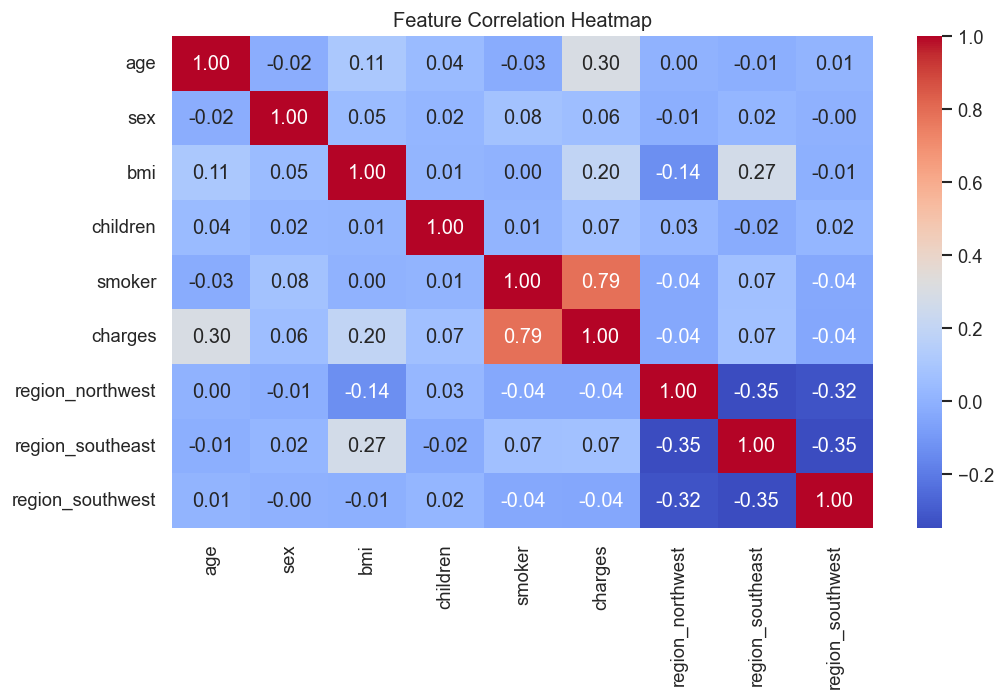

In [11]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.savefig("insurance_correlation.png")
plt.show()

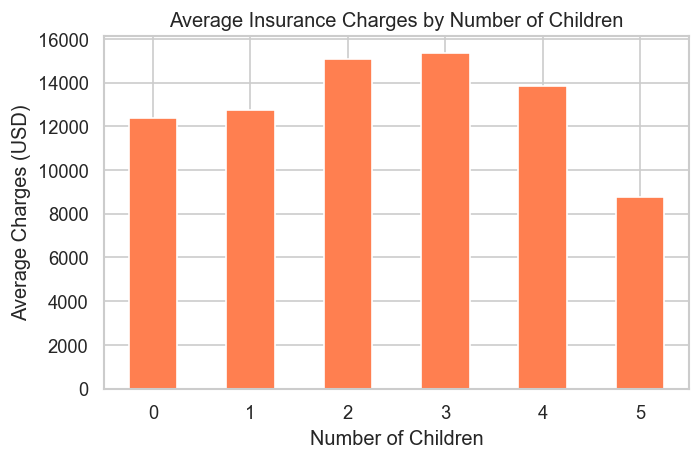

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))
df.groupby("children")["charges"].mean().plot(
    kind="bar", color="coral", ax=ax
)
ax.set_title("Average Insurance Charges by Number of Children")
ax.set_xlabel("Number of Children")
ax.set_ylabel("Average Charges (USD)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig("children_vs_charges.png")
plt.show()

In [14]:
# --- Separate features (X) and target (y) ---
X = df.drop(columns=["charges"])
y = df["charges"]
 
# --- Train/Test Split (80/20) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")
 
# %%
# --- Fit Linear Regression ---
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
 
# Predict on test set
y_pred = lr_model.predict(X_test)

Training samples: 1069
Testing samples:  268


In [15]:
# --- MAE and RMSE ---
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = lr_model.score(X_test, y_test)
 
print(f"Mean Absolute Error (MAE):  ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error (MAE):  $4,177.05
Root Mean Squared Error (RMSE): $5,956.34
R² Score: 0.8069


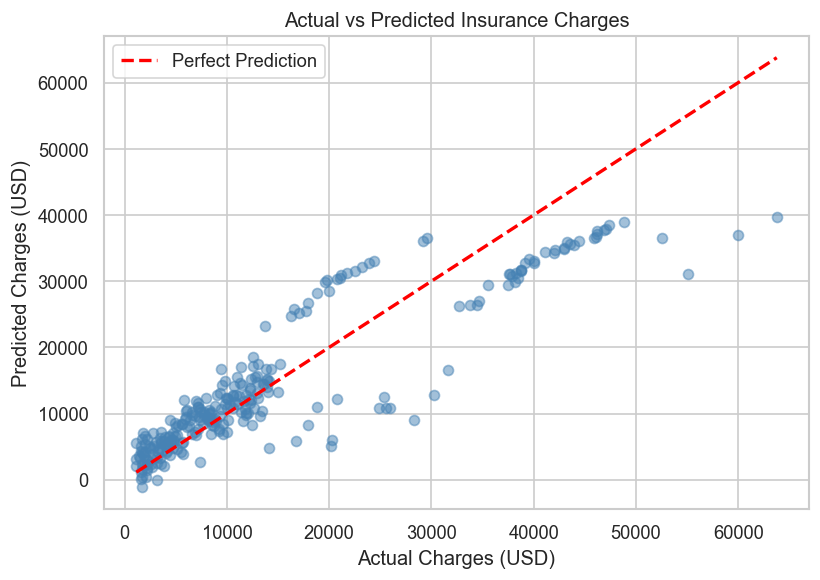

In [16]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test, y_pred, alpha=0.5, color="steelblue")
ax.plot([y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        color="red", linewidth=2, linestyle="--", label="Perfect Prediction")
ax.set_title("Actual vs Predicted Insurance Charges")
ax.set_xlabel("Actual Charges (USD)")
ax.set_ylabel("Predicted Charges (USD)")
ax.legend()
plt.tight_layout()
plt.savefig("actual_vs_predicted.png")
plt.show()

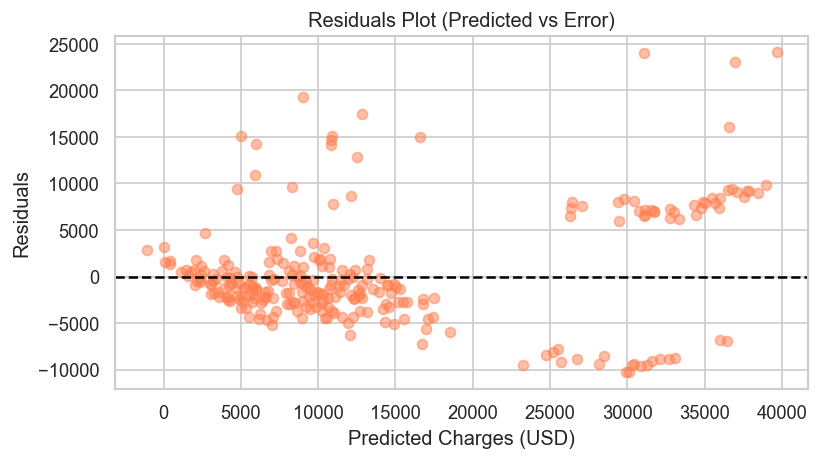

In [17]:
# --- Residuals Plot ---
residuals = y_test - y_pred
 
fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(y_pred, residuals, alpha=0.5, color="coral")
ax.axhline(y=0, color="black", linestyle="--", linewidth=1.5)
ax.set_title("Residuals Plot (Predicted vs Error)")
ax.set_xlabel("Predicted Charges (USD)")
ax.set_ylabel("Residuals")
plt.tight_layout()
plt.savefig("residuals_plot.png")
plt.show()

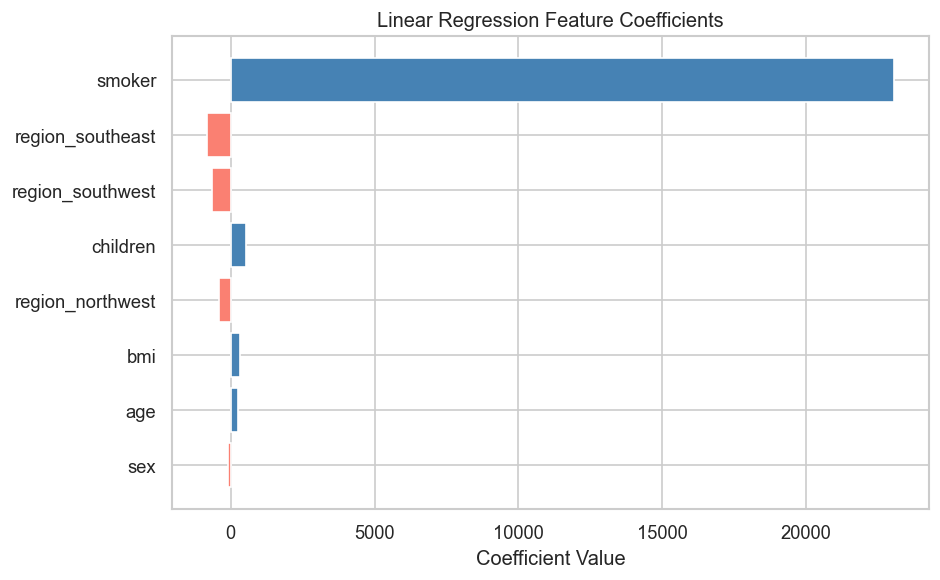

In [18]:
# --- Feature Coefficients ---
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": lr_model.coef_
}).sort_values("Coefficient", key=abs, ascending=False)
 
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["salmon" if c < 0 else "steelblue" for c in coef_df["Coefficient"]]
ax.barh(coef_df["Feature"], coef_df["Coefficient"], color=colors)
ax.set_title("Linear Regression Feature Coefficients")
ax.set_xlabel("Coefficient Value")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("feature_coefficients.png")
plt.show()

## Conclusion

- The Linear Regression model explains a good portion of variance in insurance charges (R²).
- **Smoking status** is by far the most impactful feature — smokers are charged significantly more than non-smokers.
- **Age** and **BMI** have a strong positive relationship with charges.
- Customers with higher BMI who also smoke face the steepest insurance costs.
- The model has reasonable MAE and RMSE, though non-linear models (e.g., Random Forest) could further improve predictions given the non-linear patterns visible in the data.
 